In [1]:
%env CUDA_VISIBLE_DEVICES=1
%cd ..

env: CUDA_VISIBLE_DEVICES=1
/home/ai_n_zag@lab.graphicon.ru/tmp/kolobok


In [2]:
import json
from pathlib import Path

import numpy as np
import cv2

from matplotlib import pyplot as plt

import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import read_image

from tqdm import tqdm

from tire_vision.spike_counter import UNet

images_dir = Path("data/dataset_crop")
labels_path = Path("data/result.json")

In [3]:
with open(labels_path, "r") as f:
    labels = json.load(f)

for i in range(len(labels["images"])):
    name = labels["images"][i]["file_name"]
    name = images_dir / name.split("/")[-1]
    labels["images"][i]["file_name"] = name

In [4]:
class SegmentationDataset(Dataset):
    def __init__(self, labels: dict, spikeless_odds: float = 0):
        self.labels = labels

        all_images = [Path(img["file_name"]) for img in labels["images"]]
        self.spikeless_proportion = spikeless_odds

        self.spiky_data = {}

        for annotation in labels["annotations"]:
            img_id = annotation["image_id"]
            if img_id not in self.spiky_data:
                self.spiky_data[img_id] = {
                    "image_path": Path(labels["images"][img_id]["file_name"]),
                    "segmentation": [],
                }

            self.spiky_data[img_id]["segmentation"].append(
                np.array(annotation["segmentation"], dtype=np.int32).reshape(-1, 2)
            )

        spiky_images = {img["image_path"].name for img in self.spiky_data.values()}
        spikeless_images = list(
            filter(lambda x: x.name not in spiky_images, all_images)
        )

        num_spikeless_images = int(spikeless_odds * len(self.spiky_data))

        self.spiky_data = [self.spiky_data[k] for k in sorted(self.spiky_data.keys())]
        self.spikeless_data = [
            {"image_path": img, "segmentation": []}
            for img in np.random.choice(
                spikeless_images,
                size=min(num_spikeless_images, len(spikeless_images)),
                replace=False,
            )
        ]

    def __len__(self):
        return len(self.spiky_data) + len(self.spikeless_data)

    def __getitem__(self, idx: int):
        if idx < len(self.spiky_data):
            data_point = self.spiky_data[idx]
        else:
            data_point = self.spikeless_data[idx - len(self.spiky_data)]
        img_path = str(data_point["image_path"])

        segmentation = data_point["segmentation"]

        img = read_image(img_path) / 255.0
        seg = torch.from_numpy(
            cv2.fillPoly(
                np.zeros(list(img.shape[1:]), dtype=np.uint8), segmentation, color=1
            )
        ).to(torch.float32)

        return img, seg


In [5]:
class SegmentationLoss(nn.Module):
    def __init__(
        self,
        dice_coef: float = 0.5,
        focal_coef: float = 0.5,
        focal_gamma: float = 2.5,
    ):
        super().__init__()
        self.dice_coef = dice_coef
        self.focal_coef = focal_coef
        self.focal_gamma = focal_gamma

    def focal_loss(self, pred: torch.Tensor, targ: torch.Tensor):
        return torch.mean(
            -targ * (1 - pred) ** self.focal_gamma * torch.log(pred)
            - (1 - targ) * pred**self.focal_gamma * torch.log(1 - pred)
        )

    def dice_loss(self, pred: torch.Tensor, targ: torch.Tensor):
        return 1 - torch.mean(pred * targ + 1) / torch.mean(pred + targ + 1)

    def forward(self, pred: torch.Tensor, targ: torch.Tensor):
        return (
            self.dice_coef * self.dice_loss(pred, targ) 
            + self.focal_coef * self.focal_loss(pred, targ)
        )

In [6]:
dataset = SegmentationDataset(labels, spikeless_odds=1)
print(f"total number of images: {len(dataset)}")

train_dataset, val_dataset = random_split(dataset, [0.75, 0.25])
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=8)

model = UNet(n_channels=3, n_classes=1, bilinear=False)

total number of images: 82


In [7]:
def train_fn(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: str,
    gradient_accumulation_steps: int = 1,
    n_epochs: int = 5,
):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.1,
        patience=3,
    )
    loss_fn = SegmentationLoss()

    for epoch in range(1, n_epochs + 1):
        model.train()
        running_loss = 0
        accumulated_loss = 0
        train_loop = tqdm(train_loader, desc=f"[{epoch}/{n_epochs}] Train Epoch")

        for i, (x, y) in enumerate(train_loop):
            x = x.to(device)
            y = y.to(device)

            y_hat = F.sigmoid(model(x)).squeeze(1)
            loss = loss_fn(y_hat, y)
            accumulated_loss += loss / gradient_accumulation_steps

            if (i + 1) % gradient_accumulation_steps == 0 or i == len(train_loader) - 1:
                optimizer.zero_grad()
                accumulated_loss.backward()
                optimizer.step()
                accumulated_loss = 0

            running_loss += loss.item()

            train_loop.set_postfix(loss=running_loss / (i + 1))

        model.eval()
        running_loss = 0
        eval_loop = tqdm(val_loader, desc=f"[{epoch}/{n_epochs}] Evaluation Epoch")

        with torch.no_grad():
            for i, (x, y) in enumerate(eval_loop):
                x = x.to(device)
                y = y.to(device)

                y_hat = F.sigmoid(model(x)).squeeze(1)
                loss = loss_fn(y_hat, y)

                running_loss += loss.item()

                eval_loop.set_postfix(loss=running_loss / (i + 1))

        scheduler.step(metrics=running_loss / (i + 1))


In [8]:
def get_num_params(model: nn.Module):
    return sum(param.numel() for param in model.parameters())

get_num_params(model)

31037633

In [9]:
train_fn(
    model,
    train_loader,
    val_loader,
    "cuda",
    gradient_accumulation_steps=1,
    n_epochs=25,
)

[1/25] Train Epoch:   0%|          | 0/62 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 34.00 MiB. GPU 0 has a total capacity of 23.68 GiB of which 30.88 MiB is free. Process 2558287 has 20.96 GiB memory in use. Including non-PyTorch memory, this process has 2.69 GiB memory in use. Of the allocated memory 2.34 GiB is allocated by PyTorch, and 56.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

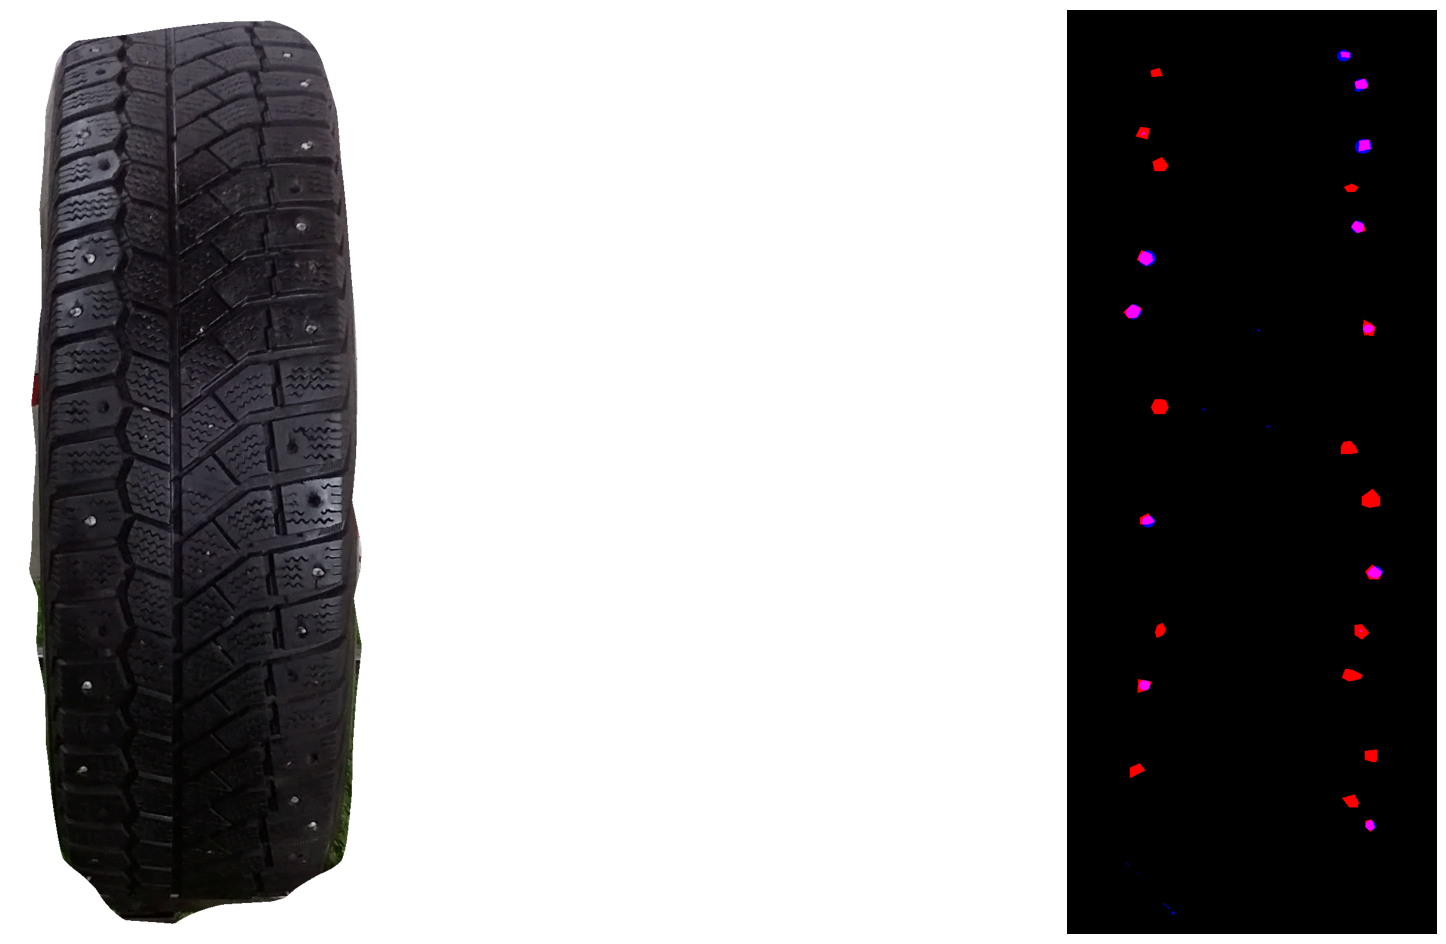

In [ ]:
model.eval()
img, gt_mask = val_dataset[2]

pred_mask = F.sigmoid(model(img[None].to("cuda")).cpu().squeeze()) > 0.25

fig, axes = plt.subplots(ncols=2, figsize=(15, 12))

axes[0].imshow(img.permute(1, 2, 0))
axes[1].imshow(torch.stack([torch.zeros_like(pred_mask), gt_mask, pred_mask], dim=-1))


for ax in axes:
    ax.axis("off")

plt.show()